In [ ]:
#Test Installation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Everything works!")

Everything works!


In [35]:
#Generate Dataset
np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "customer_id": range(1, n + 1),

    "age": np.random.randint(18, 65, n),

    "gender": np.random.choice(
        ["Male", "Female"], n
    ),

    "country": np.random.choice(
        ["USA", "UK", "Canada", "Germany", "Ghana"],
        n
    ),

    "session_duration": np.random.normal(30, 10, n),

    "pages_viewed": np.random.randint(1, 50, n),

    "products_viewed": np.random.randint(1, 20, n),

    "cart_items": np.random.randint(0, 10, n),

    "purchases": np.random.randint(0, 5, n),

    "total_spent": np.random.normal(200, 80, n),

    "last_login_days": np.random.randint(1, 60, n),

    "preferred_device": np.random.choice(
        ["Mobile", "Desktop"], n
    ),

    "membership": np.random.choice(
        ["Basic", "Premium"], n
    )
})


In [36]:
#Create Churn Column
data["churn"] = np.where(
    (data["last_login_days"] > 30) &
    (data["purchases"] < 1),
    1,
    0
)

In [37]:
#Save Dataset
data.to_csv(
    "../data/ecommerce_customers.csv",
    index=False
)

In [38]:
#Preview Dataset
data.head()

,customer_id,age,gender,country,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,preferred_device,membership,churn
0,1,56,Male,Ghana,27.256474,6,9,5,3,139.772956,7,Mobile,Basic,0
1,2,46,Female,USA,35.725133,49,5,5,2,387.566946,4,Mobile,Basic,0
2,3,32,Male,UK,26.128741,17,5,1,3,175.381797,53,Mobile,Premium,0
3,4,60,Male,Ghana,30.348922,25,8,4,2,253.552872,55,Desktop,Basic,0
4,5,25,Male,Ghana,52.365529,24,2,0,0,63.060843,8,Mobile,Premium,0


# Exploratory Data Analysis (EDA)

In [39]:
#CHECK DATASET SHAPE
data.shape

(5000, 14)

In [40]:
#VIEW COLUMN INFORMATION
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   int64  
 1   age               5000 non-null   int32  
 2   gender            5000 non-null   str    
 3   country           5000 non-null   str    
 4   session_duration  5000 non-null   float64
 5   pages_viewed      5000 non-null   int32  
 6   products_viewed   5000 non-null   int32  
 7   cart_items        5000 non-null   int32  
 8   purchases         5000 non-null   int32  
 9   total_spent       5000 non-null   float64
 10  last_login_days   5000 non-null   int32  
 11  preferred_device  5000 non-null   str    
 12  membership        5000 non-null   str    
 13  churn             5000 non-null   int64  
dtypes: float64(2), int32(6), int64(2), str(4)
memory usage: 429.8 KB


In [41]:
#SUMMARY STATISTICS
data.describe()

,customer_id,age,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,churn
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,41.16820,29.934779,25.236800,10.037200,4.593600,2.002400,201.404322,30.119000,0.099400
std,1443.520003,13.53105,10.039302,14.112723,5.457708,2.850485,1.408116,79.306769,17.060148,0.299228
min,1.000000,18.00000,-4.257954,1.000000,1.000000,0.000000,0.000000,-117.416916,1.000000,0.000000
25%,1250.750000,29.00000,23.158995,13.000000,5.000000,2.000000,1.000000,146.151416,16.000000,0.000000
50%,2500.500000,41.00000,29.887127,25.000000,10.000000,5.000000,2.000000,201.301583,30.000000,0.000000
75%,3750.250000,53.00000,36.749263,37.000000,15.000000,7.000000,3.000000,254.382250,45.000000,0.000000
max,5000.000000,64.00000,64.186122,49.000000,19.000000,9.000000,4.000000,470.579430,59.000000,1.000000


In [42]:
#CHECK MISSING VALUES
data.isnull().sum()

customer_id         0
age                 0
gender              0
country             0
session_duration    0
pages_viewed        0
products_viewed     0
cart_items          0
purchases           0
total_spent         0
last_login_days     0
preferred_device    0
membership          0
churn               0
dtype: int64

In [43]:
#CREATE ARTIFICIAL MISSING VALUES
data.loc[
    data.sample(frac=0.02).index,
    "age"
] = np.nan

In [44]:
#CHECK MISSING VALUES AGAIN
data.isnull().sum()

customer_id           0
age                 100
gender                0
country               0
session_duration      0
pages_viewed          0
products_viewed       0
cart_items            0
purchases             0
total_spent           0
last_login_days       0
preferred_device      0
membership            0
churn                 0
dtype: int64

In [45]:
#HANDLE MISSING VALUES -This replaces missing ages with the median age.
data["age"] = data["age"].fillna(
    data["age"].median()

)

In [46]:
#CHECK MISSING VALUES
data.isnull().sum()

customer_id         0
age                 0
gender              0
country             0
session_duration    0
pages_viewed        0
products_viewed     0
cart_items          0
purchases           0
total_spent         0
last_login_days     0
preferred_device    0
membership          0
churn               0
dtype: int64

In [47]:
#CHECK DUPLICATES
data.duplicated().sum()

np.int64(0)

In [48]:
#REMOVE DUPLICATES
data.drop_duplicates(inplace=True)

# Data Visualization

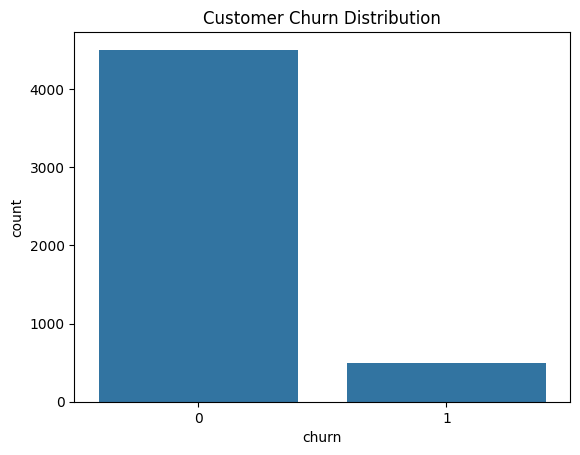

In [49]:
#CUSTOMER CHURN DISTRIBUTION
sns.countplot(
    x="churn",
    data=data
)

plt.title("Customer Churn Distribution")

plt.show()

This visualizes:

active customers
churned customers

In [ ]:
#save the churn diagram to visuals folder
plt.savefig(
    "../visuals/churn_distribution.png"
)

<Figure size 640x480 with 0 Axes>

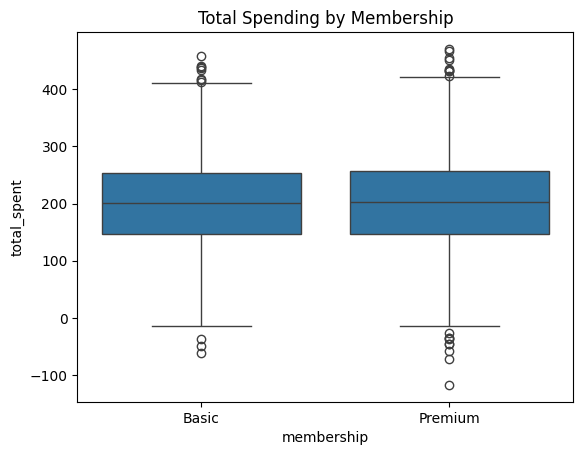

In [ ]:
#MEMBERSHIP VS SPENDING
sns.boxplot(
    x="membership",
    y="total_spent",
    data=data
)

plt.title("Total Spending by Membership")



plt.show()

Insight:

compare Premium vs Basic spending

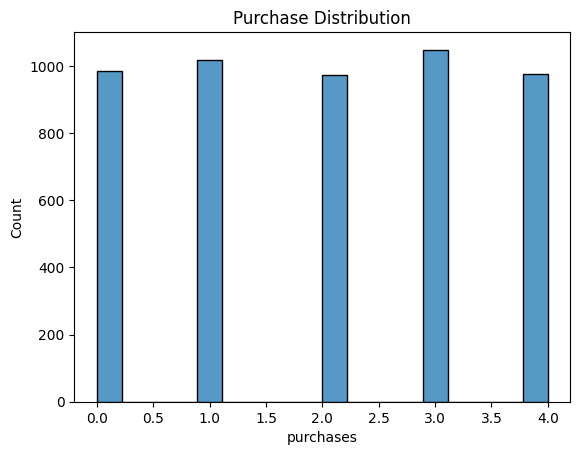

In [52]:
#PURCHASE DISTRIBUTION
sns.histplot(data["purchases"])

plt.title("Purchase Distribution")

plt.show()


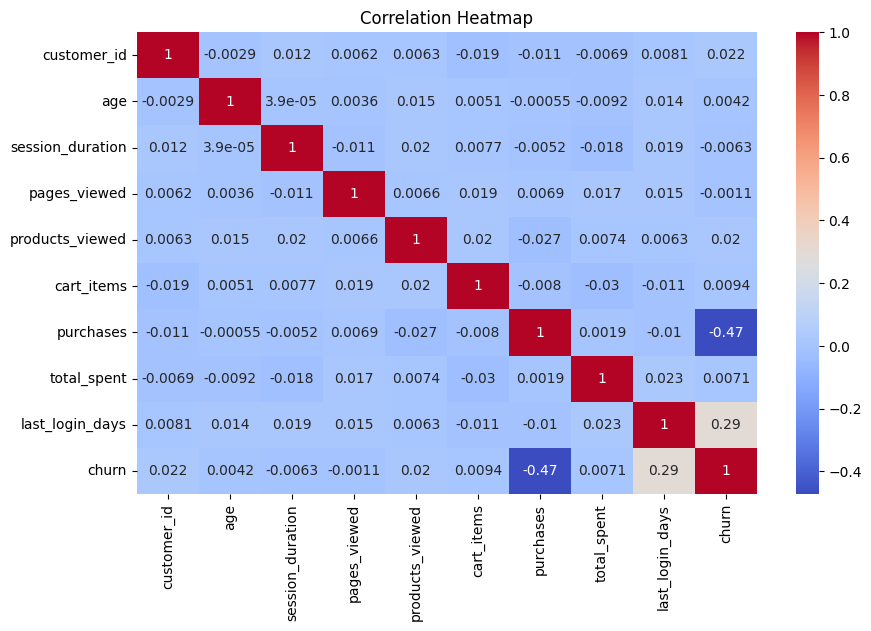

In [53]:
#CORRELATION HEATMAP
plt.figure(figsize=(10, 6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

This is VERY important for EDA.

# Feature Engineering

In [54]:
#CREATE NEW FEATURES
data["spending_per_purchase"] = (
    data["total_spent"] /
    (data["purchases"] + 1)
)

data["engagement_score"] = (
    data["pages_viewed"] +
    data["products_viewed"] +
    data["cart_items"]
)

In [55]:
data.head()

,customer_id,age,gender,country,session_duration,pages_viewed,products_viewed,cart_items,purchases,total_spent,last_login_days,preferred_device,membership,churn,spending_per_purchase,engagement_score
0,1,56.0,Male,Ghana,27.256474,6,9,5,3,139.772956,7,Mobile,Basic,0,34.943239,20
1,2,46.0,Female,USA,35.725133,49,5,5,2,387.566946,4,Mobile,Basic,0,129.188982,59
2,3,32.0,Male,UK,26.128741,17,5,1,3,175.381797,53,Mobile,Premium,0,43.845449,23
3,4,60.0,Male,Ghana,30.348922,25,8,4,2,253.552872,55,Desktop,Basic,0,84.517624,37
4,5,25.0,Male,Ghana,52.365529,24,2,0,0,63.060843,8,Mobile,Premium,0,63.060843,26


You should now see:

spending_per_purchase
engagement_score

# Data Preprocessing

In [56]:
#LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = [
    "gender",
    "country",
    "preferred_device",
    "membership"
]

for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

In [57]:
#DEFINE FEATURES AND TARGET
X = data.drop(
    ["customer_id", "churn"],
    axis=1
)

y = data["churn"]

In [58]:
#SCALE FEATURES
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Predictive Modeling

In [59]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
#TRAIN RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
#MAKE PREDICTIONS
predictions = model.predict(X_test)

# Model Evaluation

In [62]:
#ACCURACY + CLASSIFICATION REPORT
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       898
           1       1.00      1.00      1.00       102

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



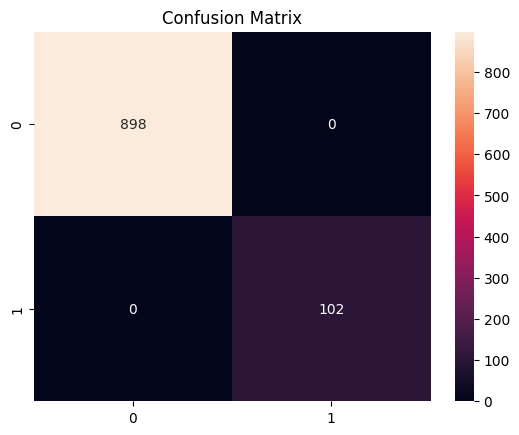

In [63]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [64]:
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5
)

print(scores)

print("Average Score:", scores.mean())

[1. 1. 1. 1. 1.]
Average Score: 1.0


# Feature Importance Analysis

In [65]:
#CALCULATE FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,purchases,0.387667
9,last_login_days,0.324355
12,spending_per_purchase,0.183206
8,total_spent,0.027356
3,session_duration,0.014241
0,age,0.012172
13,engagement_score,0.011253
4,pages_viewed,0.010851
5,products_viewed,0.009442
6,cart_items,0.008666


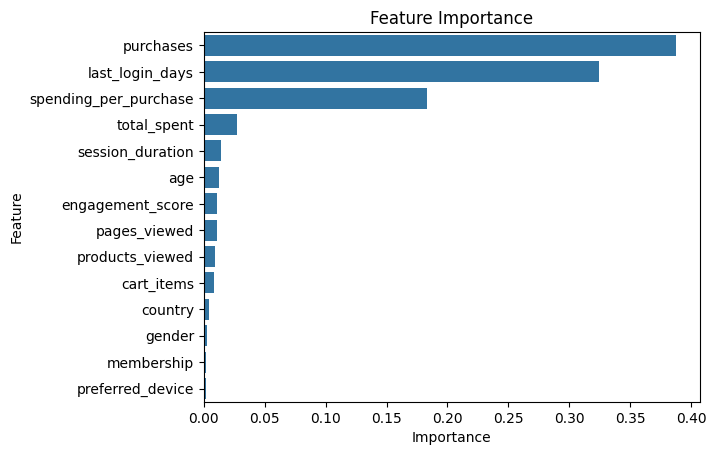

In [66]:
#FEATURE IMPORTANCE CHART
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Business Insights

1. Customers inactive for many days are more likely to churn.

2. Premium members spend more than basic members.

3. Higher engagement scores reduce churn probability.

4. Purchase frequency strongly impacts customer retention.

# Recommendations

1. Launch targeted retention campaigns.

2. Reward highly engaged customers.

3. Improve personalized recommendations.

4. Encourage repeat purchases through loyalty programs.

# Big Data Tool Utilization

Apache Kafka can be used to stream customer
interaction data in real time.

Grafana can monitor:
- customer churn
- purchasing trends
- engagement metrics

This architecture supports scalable analytics
for large e-commerce systems.

# Conclusion

This project successfully analyzed customer
behavior using synthetic e-commerce data.

Machine learning techniques were used to predict
customer churn and derive actionable insights
that can improve customer retention and sales.